## Initializing polymer systems using a DPD potential
This notebook walks through the PhantomWalk functions for packing linear polymers in a box. The polymers are first placed in a cubic box using a random walk. Then a short HOOMD simulation is run with the soft force potential of Dissipative Particle Dynamics. The simulation ends when the pair energy from the DPD potential reaches a stable state, as checked with an autocorrelation function.

In [2]:
import matplotlib
import numpy as np  
import gsd, gsd.hoomd 
import hoomd 
from cmeutils.sampling import is_equilibrated
import time
import freud
import matplotlib_inline
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.style.use("ggplot")
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [40]:
def initialize_snapshot(r_cut):
    """
    Creat a two-particle simulation box.

    """   
    L = 4 * r_cut
    positions = np.array([[0,0,0],[0,0,1e-4]])
    frame = gsd.hoomd.Frame()
    frame.particles.types = ['A']
    frame.particles.N = 2
    frame.particles.position = positions
    frame.configuration.box = [L, L, L, 0, 0, 0]
    return frame

def check_pair_energy():
    """Check whether the pair interaction energy has equilibrated.

    Pair energies are read from the HOOMD log file and analyzed
    using pymbar timeseries equilibration detection.

    Parameters
    ----------


    Returns
    -------
    bool
        True if the pair energy timeseries is determined
        to be equilibrated, otherwise False.

    """
    log = np.genfromtxt("log.txt", names=True)
    pairs = log["mdpairDPDenergy"]
    return pairs[-1]

def run_nvt_dpd_simulation(A=1000,gamma=1000,kT=1.0,r_cut = 1.15,dt=0.001,particle_spacing = 1.1):
    """Run a single polymer equilibration simulation in HOOMD-blue.

    Parameters
    ----------
    A : float, optional, default 1000
        Conservative force parameter for the DPD interaction.

    gamma : float, optional, default 1000
        Dissipative force coefficient for the DPD interaction.

    kT : float, optional, default 1.0
        Thermal energy used by the DPD thermostat.

    r_cut : float, optional, default 1.15
        Cutoff radius for DPD interactions.

    dt : float, optional, default 0.001
        Simulation integration timestep.

    particle_spacing : float, optional, default 1.1
        Maximum acceptable bond length during equilibration.

    Returns
    -------
    tuple[int, float]
        Tuple containing:
        - total number of particles
        - elapsed runtime in seconds

        If equilibration fails due to timeout,
        runtime is returned as 0.

    """
    print(f"\nRunning with A={A}, gamma={gamma}, r_cut={r_cut}")
    frame = initialize_snapshot(r_cut=r_cut)
    integrator = hoomd.md.Integrator(dt=dt)
    simulation = hoomd.Simulation(device=hoomd.device.auto_select(), seed=np.random.randint(65535))# TODO seed
    simulation.operations.integrator = integrator 
    simulation.create_state_from_snapshot(frame)
    const_vol = hoomd.md.methods.ConstantVolume(filter=hoomd.filter.All())
    integrator.methods.append(const_vol)
    nlist = hoomd.md.nlist.Cell(buffer=0.4)
    simulation.operations.nlist = nlist
    DPD = hoomd.md.pair.DPD(nlist, default_r_cut=r_cut, kT=kT)
    DPD.params[('A', 'A')] = dict(A=A, gamma=gamma)
    integrator.forces.append(DPD)
    
    simulation.run(0)
    r_values = np.linspace(1.1e-4, r_cut, 500)  # avoid exact 0
    energy=[]
    
    tags1 = np.array([0], dtype=np.int32)  # particle 0
    tags2 = np.array([1], dtype=np.int32)  # particle 1
    
    for r in r_values:
        with simulation.state.cpu_local_snapshot as snap:
            snap.particles.position[1, 2] = r
        simulation.run(0)
        U = DPD.compute_energy(tags1=tags1, tags2=tags2)
        energy.append(U)
    return energy,r_values

In [42]:
energy,r = run_nvt_dpd_simulation(A=1000,gamma=800,r_cut=1.15)


Running with A=1000, gamma=800, r_cut=1.15


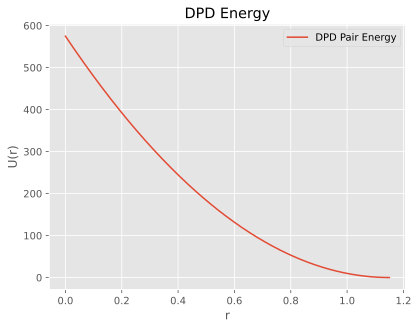

In [43]:
plt.plot(r,energy, label="DPD Pair Energy")
plt.title("DPD Energy")
plt.xlabel("r")
plt.ylabel("U(r)")

plt.legend()

## Visualize the Energy

Total steps 150100


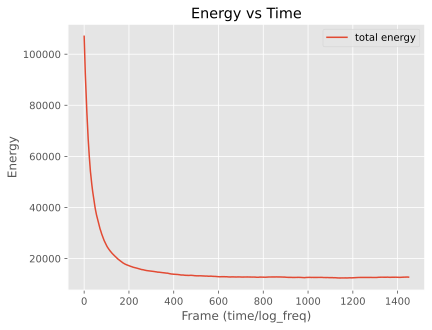

In [7]:
log = np.genfromtxt("log.txt", names=True)
pe = log["mdcomputeThermodynamicQuantitiespotential_energy"]
bonds = log["mdbondHarmonicenergy"]
pairs = log["mdpairDPDenergy"]
ke = log["mdcomputeThermodynamicQuantitieskinetic_energy"]
kinetic_temp = log["mdcomputeThermodynamicQuantitieskinetic_temperature"]
print("Total steps",len(pe)*100+100)
cut = 50
plt.plot(pe[cut:]+ke[cut:], label="total energy")
#plt.plot(kinetic_temp[cut:], label="Kinetic temperature")
#plt.plot(bonds[cut:], label="bonds")
#plt.plot(pairs[cut:], label="DPD pair")
plt.title("Energy vs Time")
plt.xlabel("Frame (time/log_freq)")
plt.ylabel("Energy")

plt.legend()

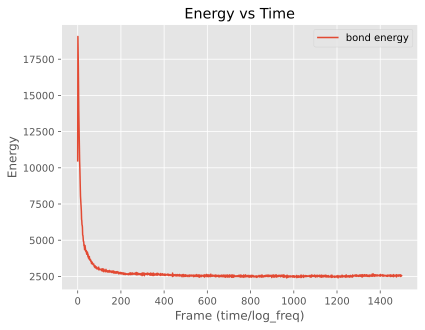

In [5]:
plt.plot(bonds, label="bond energy")
plt.title("Energy vs Time")
plt.xlabel("Frame (time/log_freq)")
plt.ylabel("Energy")

plt.legend()